In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from drs4_parser.parser import event_stream, read_first_n, file_properties
from drs4_parser.parser import print_file_properties
from drs4_parser.events_filter.coincidence import event_coincidence_filter
from drs4_parser.time_analysis import cfd_linear, cfd_analog_time
from drs4_parser.pals import good_event, read_lifetime

from drs4_parser.energy_analysis.baseline import baseline_estimation
from drs4_parser.energy_analysis.pulse_height import pulse_height_3pts_parabolic, pulse_height_robust

In [4]:
# --------- CONFIG ---------
bin_file = "F:/Data/lifetime/drs4_bin.dat"
max_events = 10000
channels = file_properties(bin_file).channels[1:]
BINS_IN_WAVEFORM = 1024
# --------------------------


estimate energy treshold 

In [5]:
da = read_first_n(bin_file, max_events)

In [6]:
ch1_t, ch1_v = da['time'].sel(channel=[channels[0]]).values[0], da['voltage'].sel(channel=[channels[0]]).values[0]
ch2_t, ch2_v = da['time'].sel(channel=[channels[1]]).values[0], da['voltage'].sel(channel=[channels[1]]).values[0]

ch1_height = -pulse_height_robust(ch1_t, ch1_v)
ch2_height = -pulse_height_robust(ch2_t, ch2_v)

ch1_count, ch1_bins = np.histogram(ch1_height[np.isfinite(ch1_height)], bins=1024)
ch2_count, ch2_bins = np.histogram(ch2_height[np.isfinite(ch2_height)], bins=1024)

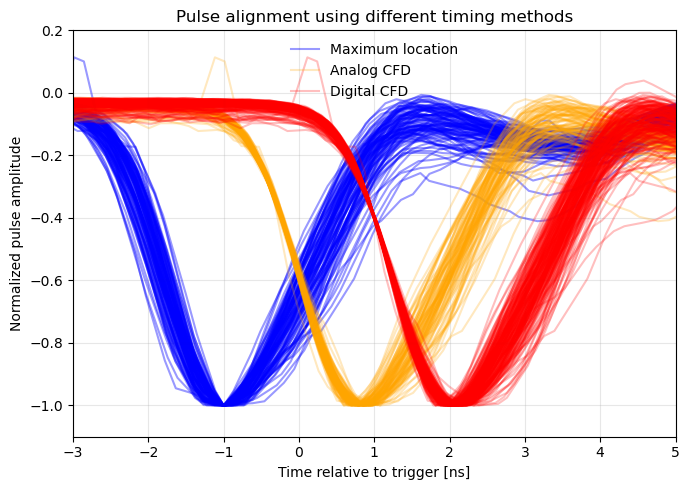

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

# --- Maximum location alignment ---
for i in range(100):
    t0 = ch2_t[i][np.argmin(ch2_v[i])]
    ax.plot(
        ch2_t[i] - t0-1,
        ch2_v[i] / np.abs(ch2_v[i].min()),
        color='blue',
        alpha=0.4,
        label='Maximum location' if i == 0 else None
    )

# --- Analog CFD alignment ---
for i in range(100):
    t0 = cfd_analog_time(
        ch2_t[i],
        ch2_v[i],
        fraction=0.3,
        delay_time=1.4
    )
    ax.plot(
        ch2_t[i] - t0 +1 ,
        ch2_v[i] / np.abs(ch2_v[i].min()),
        color='orange',
        alpha=0.25,
        label='Analog CFD' if i == 0 else None
    )

# --- Digital CFD alignment ---
for i in range(200):
    t0 = cfd_linear(
        ch2_t[i],
        ch2_v[i],
        fraction=0.4
    )
    ax.plot(
        ch2_t[i] - t0 + 1,
        ch2_v[i] / np.abs(ch2_v[i].min()),
        color='red',
        alpha=0.25,
        label='Digital CFD' if i == 0 else None
    )

# --- Formatting ---
ax.set_xlim(-3, 5)
ax.set_ylim(-1.1, 0.2)

ax.set_xlabel(r'Time relative to trigger [ns]')
ax.set_ylabel(r'Normalized pulse amplitude')
ax.set_title('Pulse alignment using different timing methods')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()
